### Simple BMI Calculator Using LangGraph

In [32]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict

#### Define State

In [33]:
class BMIStates(TypedDict):
    weight_in_kg: float
    height_in_meter: float
    bmi: float
    category: str

#### Define Node Functions

In [34]:
def calculate_bmi(state: BMIStates) -> BMIStates:
    weight = state['weight_in_kg']
    height = state['height_in_meter']

    bmi = weight/(height**2)

    state['bmi'] = bmi

    return state

In [35]:
def calculate_bmi_category(state: BMIStates) -> BMIStates:
    bmi = state['bmi']

    if bmi < 18.5:
        category = 'Underweight'
    elif bmi >= 18.5 and bmi <=24.9:
        category = 'Normal'
    elif bmi >= 25 and bmi <= 29.9:
        category = 'Overweight'
    else:
        category = 'Obese'

    state['category'] = category

    return state

#### Create Graph

In [36]:
graph = StateGraph(BMIStates)

#### Add Nodes To Graph

In [37]:
graph.add_node('BMI Calculator', calculate_bmi)
graph.add_node('Category Calculator', calculate_bmi_category)

#### Add Edges

In [38]:
graph.add_edge(START, 'BMI Calculator')
graph.add_edge('BMI Calculator', 'Category Calculator')
graph.add_edge('Category Calculator', END)

#### Compile Graph

In [39]:
workflow = graph.compile()

#### Print Graph

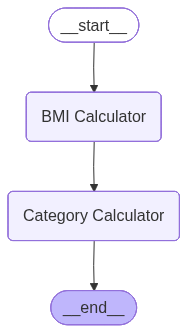

In [40]:
from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png())

#### Execute the graph

In [41]:
initial_state = {
    'weight_in_kg': 59.9,
    'height_in_meter': 1.69
}

final_state = workflow.invoke(initial_state)

print(final_state)

{'weight_in_kg': 59.9, 'height_in_meter': 1.69, 'bmi': 20.972655019081966, 'category': 'Normal'}
